# Day 9 — Churn Prediction
XGBoost classifier with SHAP explainability to identify at-risk customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

process   = Path('../Data/Processed')
figure    = Path('../Reports/Figure')
report    = Path('../Reports/Model_Reports')

CHURN_DAYS = 90   # customer not purchased in 90+ days = churned
RANDOM_STATE = 42

print('Setup done.')

c:\Users\Dharm Maniya\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup done.


In [2]:
# Load RFM dataset
rfm = pd.read_csv(process / 'retail_sales_rfm.csv', parse_dates=['FirstPurchaseDate', 'LastPurchaseDate'])

print('Shape:', rfm.shape)
print('Columns:', rfm.columns.tolist())
print('Missing values:')
print(rfm.isnull().sum())
rfm.head()

Shape: (5878, 14)
Columns: ['CustomerID', 'PrimaryCountry', 'FirstPurchaseDate', 'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'AverageOrderValue', 'CustomerLifetimeDays', 'RecencyScore', 'FrequencyScore', 'MonetaryScore', 'RFMScore']
Missing values:
CustomerID              0
PrimaryCountry          0
FirstPurchaseDate       0
LastPurchaseDate        0
Recency                 0
Frequency               0
Monetary                0
TotalQuantity           0
AverageOrderValue       0
CustomerLifetimeDays    0
RecencyScore            0
FrequencyScore          0
MonetaryScore           0
RFMScore                0
dtype: int64


,CustomerID,PrimaryCountry,FirstPurchaseDate,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,RecencyScore,FrequencyScore,MonetaryScore,RFMScore
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,326,12,77556.46,74285,6463.04,400,2,5,5,255
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00,3,8,4921.53,2967,615.19,402,5,4,5,545
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00,76,5,2019.40,2714,403.88,363,3,4,4,344
3,12349,Italy,2010-04-29 13:20:00,2011-11-21 09:51:00,19,4,4428.69,1624,1107.17,571,5,3,5,535
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,311,1,334.40,197,334.40,0,2,1,2,212


In [3]:
rfm.head()

,CustomerID,PrimaryCountry,FirstPurchaseDate,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,RecencyScore,FrequencyScore,MonetaryScore,RFMScore
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,326,12,77556.46,74285,6463.04,400,2,5,5,255
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00,3,8,4921.53,2967,615.19,402,5,4,5,545
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00,76,5,2019.40,2714,403.88,363,3,4,4,344
3,12349,Italy,2010-04-29 13:20:00,2011-11-21 09:51:00,19,4,4428.69,1624,1107.17,571,5,3,5,535
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,311,1,334.40,197,334.40,0,2,1,2,212


In [4]:
rfm.columns

Index(['CustomerID', 'PrimaryCountry', 'FirstPurchaseDate', 'LastPurchaseDate',
       'Recency', 'Frequency', 'Monetary', 'TotalQuantity',
       'AverageOrderValue', 'CustomerLifetimeDays', 'RecencyScore',
       'FrequencyScore', 'MonetaryScore', 'RFMScore'],
      dtype='str')

In [5]:
churn_df = rfm.copy()

print("Shape:",churn_df.shape)
print(churn_df.columns.tolist())

churn_df["Churned"] = (churn_df["Recency"] > 90).astype(int)

print(churn_df["Churned"].value_counts())
print("\nChurn rate:",round(churn_df["Churned"].mean()*100,2),"%")

churn_df["purchase_rate"] = churn_df["Frequency"]/(churn_df["CustomerLifetimeDays"]+1)
churn_df["revenue_per_day"] = churn_df["Monetary"]/(churn_df["CustomerLifetimeDays"]+1)
churn_df["qty_per_order"] = churn_df["TotalQuantity"]/(churn_df["Frequency"]+1)
churn_df["avg_gap"] = churn_df["CustomerLifetimeDays"]/(churn_df["Frequency"]+1)
churn_df["spend_per_visit"] = churn_df["Monetary"]/(churn_df["Frequency"]+1)
churn_df["is_one_time"] = (churn_df["Frequency"] == 1).astype(int)
churn_df["qty_per_day"] = churn_df["TotalQuantity"]/(churn_df["CustomerLifetimeDays"]+1)
churn_df["is_slow_buyer"] = (churn_df["avg_gap"] > 60).astype(int)
churn_df["aov_ratio"] = churn_df["AverageOrderValue"]/(churn_df["Monetary"]+1)

churn_df = churn_df[[
    "CustomerID","PrimaryCountry","Frequency","Monetary","TotalQuantity",
    "AverageOrderValue","CustomerLifetimeDays","FrequencyScore","MonetaryScore",
    "purchase_rate","revenue_per_day","qty_per_order","avg_gap",
    "spend_per_visit","is_one_time","qty_per_day","is_slow_buyer",
    "aov_ratio","Churned"
]].copy()

churn_df.head()

Shape: (5878, 14)
['CustomerID', 'PrimaryCountry', 'FirstPurchaseDate', 'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'AverageOrderValue', 'CustomerLifetimeDays', 'RecencyScore', 'FrequencyScore', 'MonetaryScore', 'RFMScore']
Churned
1    2989
0    2889
Name: count, dtype: int64

Churn rate: 50.85 %


,CustomerID,PrimaryCountry,Frequency,Monetary,TotalQuantity,AverageOrderValue,CustomerLifetimeDays,FrequencyScore,MonetaryScore,purchase_rate,revenue_per_day,qty_per_order,avg_gap,spend_per_visit,is_one_time,qty_per_day,is_slow_buyer,aov_ratio,Churned
0,12346,United Kingdom,12,77556.46,74285,6463.04,400,5,5,0.029925,193.407631,5714.230769,30.769231,5965.881538,0,185.249377,0,0.083332,1
1,12347,Iceland,8,4921.53,2967,615.19,402,4,5,0.019851,12.212233,329.666667,44.666667,546.836667,0,7.362283,0,0.124974,0
2,12348,Finland,5,2019.40,2714,403.88,363,4,4,0.013736,5.547802,452.333333,60.500000,336.566667,0,7.456044,1,0.199901,0
3,12349,Italy,4,4428.69,1624,1107.17,571,3,5,0.006993,7.742465,324.800000,114.200000,885.738000,0,2.839161,1,0.249943,0
4,12350,Norway,1,334.40,197,334.40,0,1,2,1.000000,334.400000,98.500000,0.000000,167.200000,1,197.000000,0,0.997018,1


In [6]:
churn_df.columns

Index(['CustomerID', 'PrimaryCountry', 'Frequency', 'Monetary',
       'TotalQuantity', 'AverageOrderValue', 'CustomerLifetimeDays',
       'FrequencyScore', 'MonetaryScore', 'purchase_rate', 'revenue_per_day',
       'qty_per_order', 'avg_gap', 'spend_per_visit', 'is_one_time',
       'qty_per_day', 'is_slow_buyer', 'aov_ratio', 'Churned'],
      dtype='str')

In [7]:
FEATURES = [
    "Frequency","Monetary","TotalQuantity","AverageOrderValue",
    "CustomerLifetimeDays","purchase_rate","revenue_per_day",
    "qty_per_order","avg_gap","spend_per_visit","is_one_time",
    "qty_per_day","is_slow_buyer","aov_ratio"
]

X = churn_df[FEATURES].copy()
y = churn_df["Churned"].copy()

print("Features:",len(FEATURES))
print("X shape:",X.shape)
print("y shape:",y.shape)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

print("Train:",X_train.shape,"| Test:",X_test.shape)
print("Train churn rate:",round(y_train.mean()*100,1),"%")
print("Test churn rate:",round(y_test.mean()*100,1),"%")

Features: 14
X shape: (5878, 14)
y shape: (5878,)
Train: (4702, 14) | Test: (1176, 14)
Train churn rate: 50.9 %
Test churn rate: 50.9 %


In [8]:
# Handle class imbalance — scale_pos_weight = active/churned ratio
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {round(scale, 2)}')

model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale,
    random_state      = 42,
    eval_metric       = 'auc',
    early_stopping_rounds = 20,
    verbosity         = 0
)

model.fit(X_train, y_train,eval_set=[(X_test, y_test)],verbose=False)

print('Model trained. Best iteration:', model.best_iteration)

scale_pos_weight: 0.97
Model trained. Best iteration: 12


In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.3],
}

base = xgb.XGBClassifier(
    n_estimators=500, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale, random_state=42,
    eval_metric='auc', verbosity=0
)

grid = GridSearchCV(base, param_grid, scoring='roc_auc',
                    cv=StratifiedKFold(5), n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV AUC:', round(grid.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'gamma': 0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 1}
Best CV AUC: 0.797


In [10]:
# Evaluate
y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]

auc_roc     = roc_auc_score(y_test, y_prob)
auc_pr      = average_precision_score(y_test, y_prob)

# Cross-validation AUC
cv_model = xgb.XGBClassifier(
    n_estimators=model.best_iteration, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale,
    random_state=RANDOM_STATE, verbosity=0
)
cv_scores = cross_val_score(cv_model, X, y, cv=StratifiedKFold(5), scoring='roc_auc')

print('========== CHURN MODEL RESULTS ==========')
print(f'AUC-ROC      : {round(auc_roc, 4)}')
print(f'AUC-PR       : {round(auc_pr,  4)}')
print(f'CV AUC (5-fold): {round(cv_scores.mean(), 4)} ± {round(cv_scores.std(), 4)}')
print('Target       : AUC-ROC >= 0.88')
print('Target met   :', '✅ YES' if auc_roc >= 0.88 else '❌ NO — see tuning')
print()
print(classification_report(y_test, y_pred, target_names=['Active','Churned']))

========== CHURN MODEL RESULTS ==========
AUC-ROC      : 0.817
AUC-PR       : 0.7807
CV AUC (5-fold): 0.8007 ± 0.0143
Target       : AUC-ROC >= 0.88
Target met   : ❌ NO — see tuning

              precision    recall  f1-score   support

      Active       0.78      0.68      0.73       578
     Churned       0.72      0.81      0.77       598

    accuracy                           0.75      1176
   macro avg       0.75      0.75      0.75      1176
weighted avg       0.75      0.75      0.75      1176



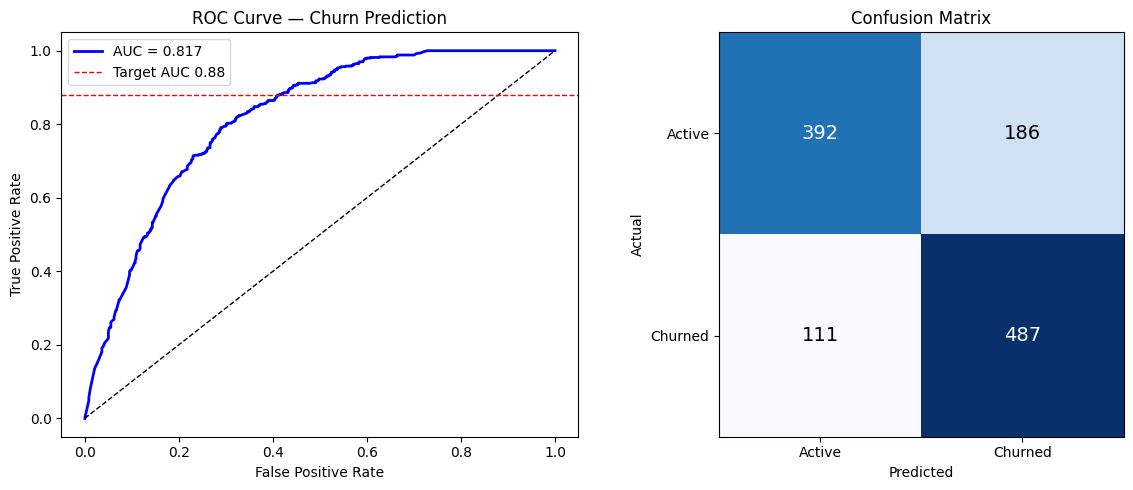

In [11]:
# Plots — ROC curve + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='Blue', linewidth=2, label=f'AUC = {round(auc_roc, 3)}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1)
axes[0].axhline(0.88, color='red', linestyle='--', linewidth=1, label='Target AUC 0.88')
axes[0].set_title('ROC Curve — Churn Prediction')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_title('Confusion Matrix')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Active','Churned'])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['Active','Churned'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.savefig(figure / '9-Churn_ROC_Confusion.png', dpi=150)
plt.show()

Features: 14
X_test shape: (1176, 14)
SHAP shape: (1176, 14)


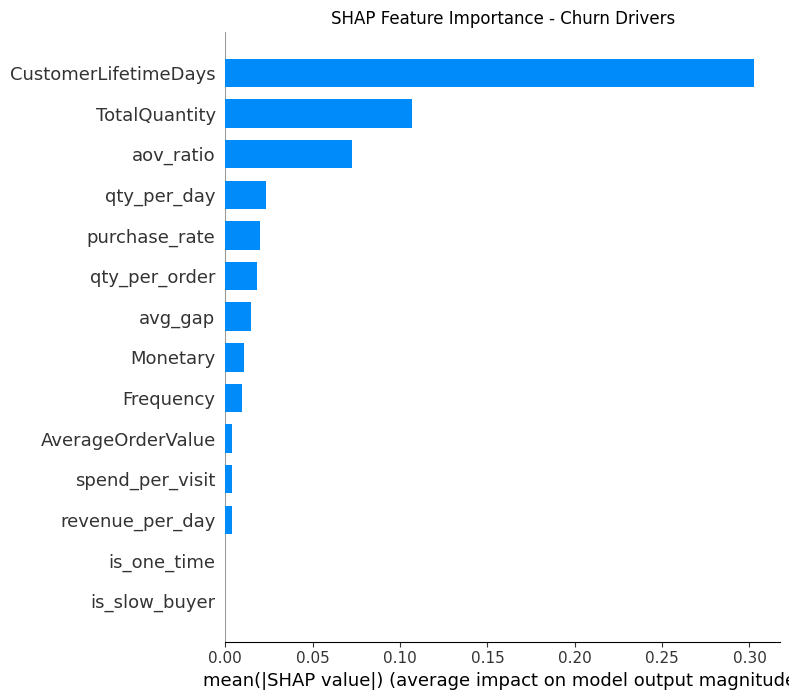

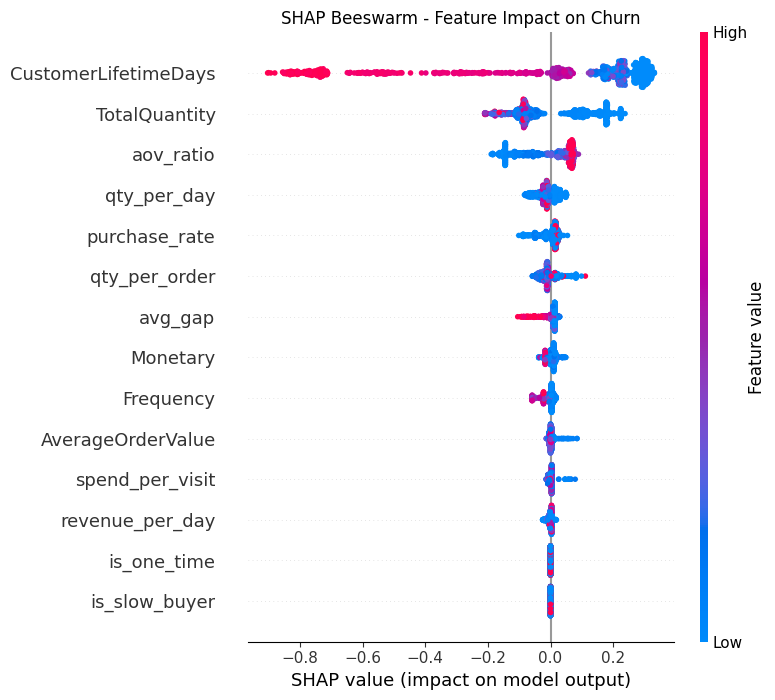

is_slow_buyer           0.000000
is_one_time             0.000000
revenue_per_day         0.003786
spend_per_visit         0.003825
AverageOrderValue       0.003944
Frequency               0.009388
Monetary                0.010874
avg_gap                 0.014622
qty_per_order           0.018020
purchase_rate           0.019576
qty_per_day             0.023139
aov_ratio               0.072335
TotalQuantity           0.107088
CustomerLifetimeDays    0.302351
dtype: float32
Dropping weak features: ['is_slow_buyer', 'is_one_time']
AUC after pruning: 0.8161
AUC before pruning: 0.817
Original model retained.


In [12]:
# SHAP explainability
FEATURES = list(model.feature_names_in_)
X_test_shap = X_test[FEATURES].copy()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_shap)

if isinstance(shap_values,list):
    shap_values = shap_values[1]

if shap_values.ndim == 3:
    shap_values = shap_values[:,:,1]

print("Features:",len(FEATURES))
print("X_test shape:",X_test_shap.shape)
print("SHAP shape:",shap_values.shape)

# --- Bar plot (feature importance) ---
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values,X_test_shap,feature_names=FEATURES,
                  plot_type="bar",show=False)
plt.title("SHAP Feature Importance - Churn Drivers")
plt.tight_layout()
plt.savefig(figure / "9-Churn_SHAP_Importance.png",dpi=150,bbox_inches="tight")
plt.show()

# --- Beeswarm (direction of impact) ---
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values,X_test_shap,feature_names=FEATURES,show=False)
plt.title("SHAP Beeswarm - Feature Impact on Churn")
plt.tight_layout()
plt.savefig(figure / "9-Churn_SHAP_Beeswarm.png",dpi=150,bbox_inches="tight")
plt.show()

# --- Feature pruning based on SHAP ---
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),index=FEATURES
).sort_values()

print(mean_shap)

weak_features = mean_shap[mean_shap < 0.001].index.tolist()

print("Dropping weak features:",weak_features)

# Retrain without weak features
if weak_features:
    FEATURES_PRUNED = [f for f in FEATURES if f not in weak_features]

    X_train_p = X_train[FEATURES_PRUNED]
    X_test_p = X_test[FEATURES_PRUNED]

    model_pruned = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=RANDOM_STATE,
        eval_metric="auc",
        early_stopping_rounds=20,
        verbosity=0
    )

    model_pruned.fit(
        X_train_p,y_train,
        eval_set=[(X_test_p,y_test)],
        verbose=False
    )

    y_prob_pruned = model_pruned.predict_proba(X_test_p)[:,1]
    auc_pruned = roc_auc_score(y_test,y_prob_pruned)

    print("AUC after pruning:",round(auc_pruned,4))
    print("AUC before pruning:",round(auc_roc,4))

    if auc_pruned > auc_roc:
        model = model_pruned
        FEATURES = FEATURES_PRUNED
        auc_roc = auc_pruned
        print("Pruned model is better - using it.")
    else:
        print("Original model retained.")
else:
    print("No weak features found.")

In [16]:
from pathlib import Path

churn_df.to_csv(process / 'retail_churn_features.csv', index=False)